In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Example with 1 sheet

In [6]:
filepath = '1. GLC Nominal daily data_1979 to 1984.xlsx'
shortEnd_sheetname = '3. nominal spot, short end'
fullCurve_sheetname = '4. nominal spot curve'

fullCurve = pd.read_excel(filepath, 
                          sheet_name=fullCurve_sheetname, 
                          header = 0, 
                          skiprows = [0, 1, 2, 4])

fullCurve = fullCurve.rename(columns={'years:': 'date'})
fullCurve =fullCurve.drop(0.5, axis = 1)


In [ ]:
frontEnd = pd.read_excel(filepath,
                          sheet_name=shortEnd_sheetname,
                          header = 0,
                          skiprows = [0, 1, 2, 4])

frontEnd.rename(columns={'years:': 'date'}, inplace=True)

frontEnd_monthIndex = pd.read_excel(filepath,
                          sheet_name=shortEnd_sheetname,
                          header = 0,
                          skiprows = [0, 1, 4]).columns

frontEnd_monthIndex = [int(x) if type(x) != str else x for x in frontEnd_monthIndex ]
SELECT_MONTHS = [1, 2, 3, 4, 5, 6, 9, 15, 21]
frontEnd_selectedIdx = [0] + [frontEnd_monthIndex.index(x) for x in SELECT_MONTHS]
frontEnd = frontEnd.iloc[:, frontEnd_selectedIdx]
frontEnd.columns = ['date'] + [round(x/12, 4) for x in SELECT_MONTHS]

fullFrame = pd.merge(frontEnd, fullCurve, on='date', how='inner')

### Loop

In [10]:
finalFrameStore = {}

SELECT_MONTHS = [1, 2, 3, 4, 5, 6, 9, 15, 21, 27, 39, 45, 51, 57]

for filename in sorted(os.listdir()):
    if not filename.endswith('.xlsx'):
        continue
    else:
        filepath = os.path.join(filename)
        print(filename)
        excel = pd.ExcelFile(filepath)
        shortEnd_sheetname = excel.sheet_names[3]
        fullCurve_sheetname = excel.sheet_names[4]
        fullCurve = pd.read_excel(filepath, 
                                sheet_name=fullCurve_sheetname, 
                                header = 0, 
                                skiprows = [0, 1, 2, 4])
        fullCurve = fullCurve.rename(columns={'years:': 'date'})
        fullCurve =fullCurve.drop(0.5, axis = 1)

        frontEnd = pd.read_excel(filepath,
                            sheet_name=shortEnd_sheetname,
                            header = 0,
                            skiprows = [0, 1, 2, 4])
        
        frontEnd.rename(columns={'years:': 'date'}, inplace=True)
        frontEnd_monthIndex = pd.read_excel(filepath,
                            sheet_name=shortEnd_sheetname,
                            header = 0,
                            skiprows = [0, 1, 4]).columns.to_list()
        frontEnd_monthIndex = [int(x) if type(x) != str else x for x in frontEnd_monthIndex ]
        
        frontEnd_selectedIdx = [0] + [frontEnd_monthIndex.index(x) for x in SELECT_MONTHS]
        frontEnd = frontEnd.iloc[:, frontEnd_selectedIdx]
        frontEnd.columns = ['date'] + [round(x/12, 4) for x in SELECT_MONTHS]

        fullFrame = pd.merge(frontEnd, fullCurve, on='date', how='inner')
        finalFrameStore[filename] = fullFrame

        

1. GLC Nominal daily data_1979 to 1984.xlsx
2. GLC Nominal daily data_1985 to 1989.xlsx
3. GLC Nominal daily data_1990 to 1994.xlsx
4. GLC Nominal daily data_1995 to 1999.xlsx
5. GLC Nominal daily data_2000 to 2004.xlsx
6. GLC Nominal daily data_2005 to 2015.xlsx
7. GLC Nominal daily data_2016 to 2024.xlsx
8. GLC Nominal daily data_2025 to present.xlsx


In [25]:
finalDf = pd.concat(finalFrameStore.values()).set_index('date')
finalDf = finalDf.sort_index(axis=1)
finalDf

,0.0833,0.1667,0.2500,0.3333,0.4167,0.5000,0.7500,1.0000,1.2500,1.5000,...,35.5000,36.0000,36.5000,37.0000,37.5000,38.0000,38.5000,39.0000,39.5000,40.0000
date,,,,,,,,,,,,,,,,,,,,,
1979-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1979-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.446775,11.597198,11.733149,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1979-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.521413,11.648574,11.770976,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1979-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.517242,11.628891,11.739487,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1979-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.463236,11.573516,11.683237,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,NaN,NaN,NaN,3.916029,3.988071,4.052041,4.190825,4.257247,4.279653,4.281319,...,5.426721,5.413264,5.399097,5.384221,5.368641,5.352360,5.335386,5.317723,5.299380,5.280365
2026-03-26,NaN,NaN,NaN,3.942199,4.025096,4.097977,4.254612,4.331616,4.361837,4.370121,...,5.547045,5.533448,5.519130,5.504096,5.488350,5.471898,5.454747,5.436902,5.418374,5.399171
2026-03-27,NaN,NaN,NaN,3.863144,3.948391,4.025965,4.202385,4.296250,4.337649,4.353051,...,5.585050,5.570670,5.555529,5.539633,5.522984,5.505590,5.487455,5.468588,5.448997,5.428693


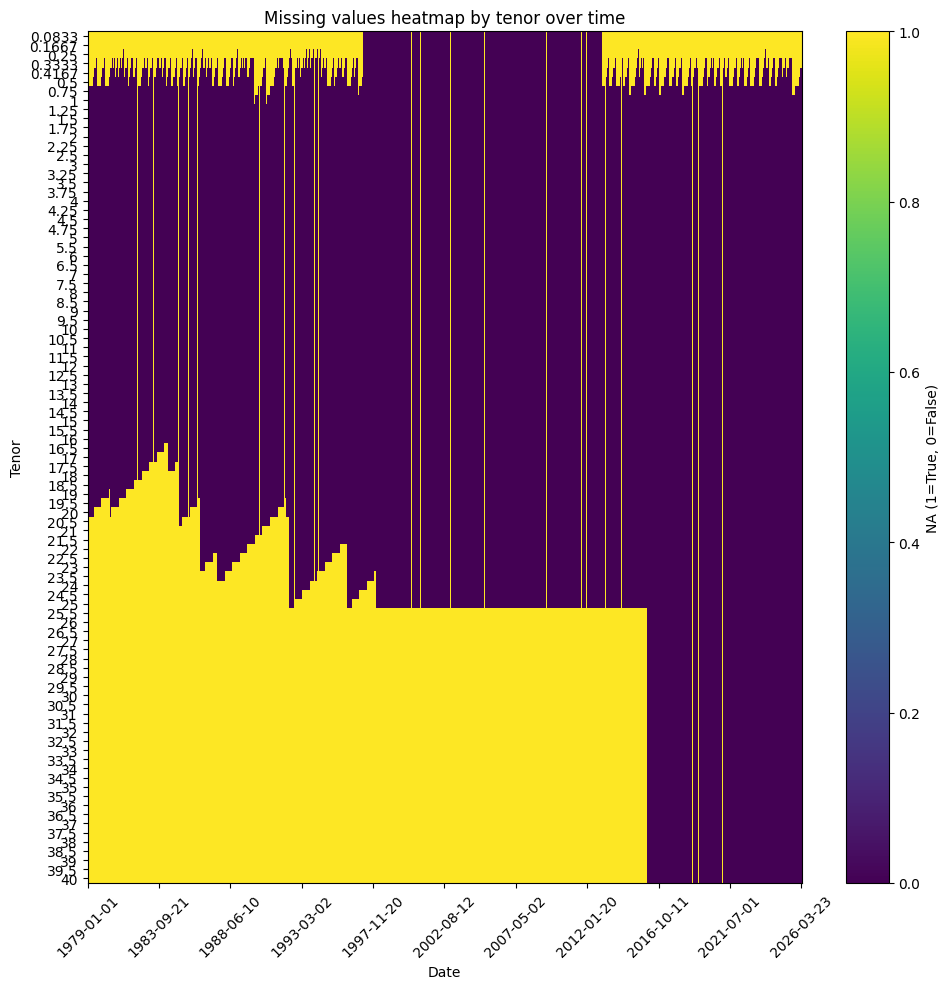

In [26]:
na_mask = finalDf.isna()

plt.figure(figsize=(10, 10))
plt.imshow(na_mask.T, aspect="auto", interpolation="nearest", cmap="viridis")
plt.colorbar(label="NA (1=True, 0=False)")

plt.yticks(range(len(finalDf.columns)), finalDf.columns)
plt.xticks(
    ticks=range(0, len(finalDf.index), max(1, len(finalDf.index)//10)),
    labels=finalDf.index[::max(1, len(finalDf.index)//10)].strftime("%Y-%m-%d"),
    rotation=45
)

plt.xlabel("Date")
plt.ylabel("Tenor")
plt.title("Missing values heatmap by tenor over time")
plt.tight_layout()
plt.show()

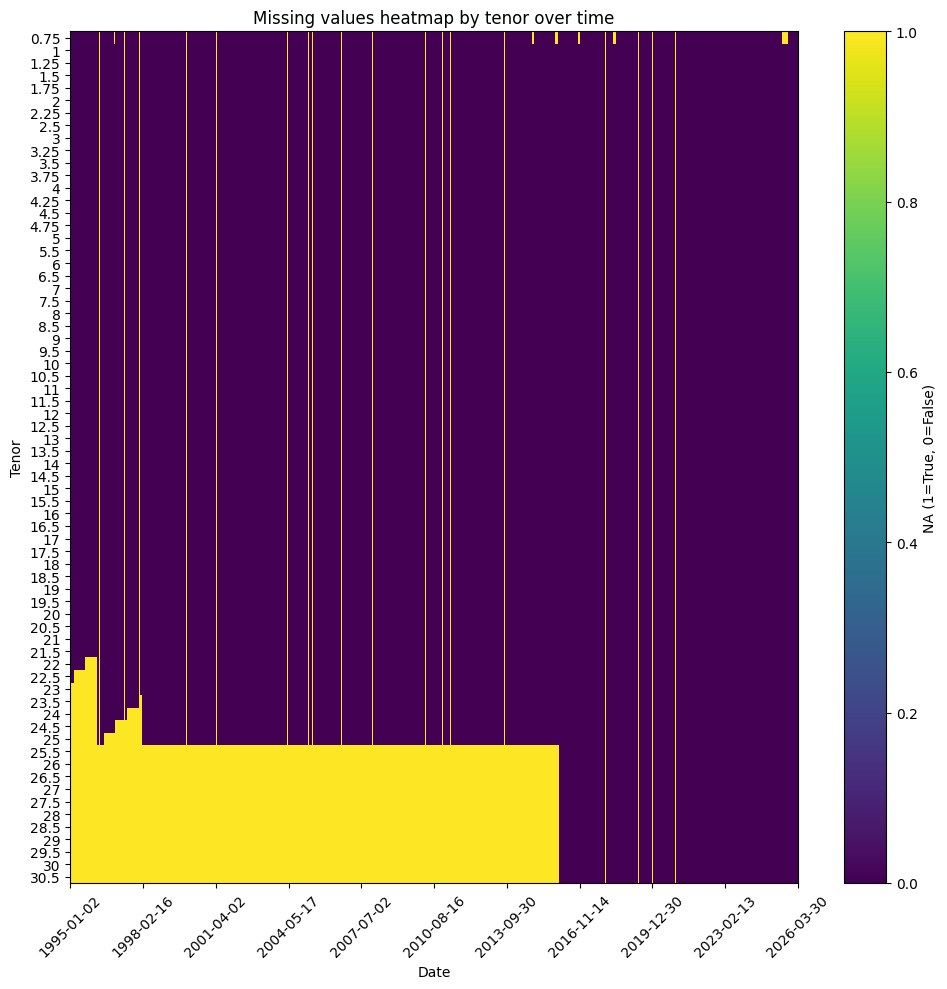

In [27]:
FILTERTENORS = [x for x in finalDf.columns if x >= 0.75 and x < 31]
STARTDATE = '1995-01-01'

filterDf = finalDf[FILTERTENORS][STARTDATE:]
na_mask = filterDf.isna()

plt.figure(figsize=(10, 10))
plt.imshow(na_mask.T, aspect="auto", interpolation="nearest", cmap="viridis")
plt.colorbar(label="NA (1=True, 0=False)")

plt.yticks(range(len(filterDf.columns)), filterDf.columns)
plt.xticks(
    ticks=range(0, len(filterDf.index), max(1, len(filterDf.index)//10)),
    labels=filterDf.index[::max(1, len(filterDf.index)//10)].strftime("%Y-%m-%d"),
    rotation=45
)

plt.xlabel("Date")
plt.ylabel("Tenor")
plt.title("Missing values heatmap by tenor over time")
plt.tight_layout()
plt.show()

In [28]:
filterDf.to_csv('bankofengland_gilt_filtered.csv')